In [1]:
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd

In [2]:
dataset =pd.read_csv('Mall_Customers.csv')

In [3]:
dataset

,CustomerID,Genre,Age,Annual Income (k$),Spending Score (1-100)
0,1,Male,19,15,39
1,2,Male,21,15,81
2,3,Female,20,16,6
3,4,Female,23,16,77
4,5,Female,31,17,40
...,...,...,...,...,...
195,196,Female,35,120,79
196,197,Female,45,126,28
197,198,Male,32,126,74
198,199,Male,32,137,18


In [4]:
X = dataset.iloc[:,[3,4]].values

In [5]:
X

array([[ 15,  39],
       [ 15,  81],
       [ 16,   6],
       [ 16,  77],
       [ 17,  40],
       [ 17,  76],
       [ 18,   6],
       [ 18,  94],
       [ 19,   3],
       [ 19,  72],
       [ 19,  14],
       [ 19,  99],
       [ 20,  15],
       [ 20,  77],
       [ 20,  13],
       [ 20,  79],
       [ 21,  35],
       [ 21,  66],
       [ 23,  29],
       [ 23,  98],
       [ 24,  35],
       [ 24,  73],
       [ 25,   5],
       [ 25,  73],
       [ 28,  14],
       [ 28,  82],
       [ 28,  32],
       [ 28,  61],
       [ 29,  31],
       [ 29,  87],
       [ 30,   4],
       [ 30,  73],
       [ 33,   4],
       [ 33,  92],
       [ 33,  14],
       [ 33,  81],
       [ 34,  17],
       [ 34,  73],
       [ 37,  26],
       [ 37,  75],
       [ 38,  35],
       [ 38,  92],
       [ 39,  36],
       [ 39,  61],
       [ 39,  28],
       [ 39,  65],
       [ 40,  55],
       [ 40,  47],
       [ 40,  42],
       [ 40,  42],
       [ 42,  52],
       [ 42,  60],
       [ 43,

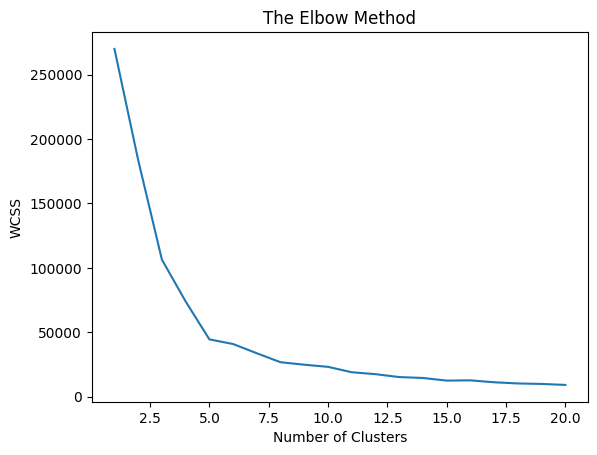

In [6]:
from sklearn.cluster import KMeans
list1=[]
for i in range(1,21):
    kmeans = KMeans(n_clusters = i, init = 'k-means++', random_state = 42)
    kmeans.fit(X)
    list1.append(kmeans.inertia_)
plt.plot(range(1,21),list1)
plt.title('The Elbow Method')
plt.xlabel('Number of Clusters')
plt.ylabel('WCSS')
plt.show()

In [7]:
from sklearn.cluster import KMeans
kmeans = KMeans(n_clusters = i, init = 'k-means++', random_state = 42)
y_kmeans =kmeans.fit_predict(X)

In [8]:
y_kmeans

array([ 6,  3,  4,  3,  6,  3,  4,  3,  4,  3,  4,  3,  4,  3,  4,  3,  6,
        8,  6,  3,  6,  8,  4,  8,  4,  8,  6,  8,  6,  8,  4,  8,  4,  8,
        4,  8,  4,  8,  6,  8, 12,  8, 12, 16,  6, 16, 16, 12, 12, 12, 16,
       16, 16, 16, 12, 12, 16, 12, 16, 12, 16, 16, 16, 16, 16, 16, 16, 12,
       16, 12, 16, 12, 15, 15,  0, 15, 15, 15, 15,  0, 15, 15,  0,  0, 15,
        0, 15, 15, 15,  0, 10,  0, 10,  0,  0, 10,  0, 10,  0, 10,  0, 10,
       10, 10, 10,  0, 10,  0,  0, 10, 10, 10,  0,  0, 10, 10,  0, 10,  0,
       10, 10, 17, 10, 14, 17,  5, 17, 14, 11,  5, 11,  5, 17,  5, 11, 14,
       11,  5, 11,  5, 11, 14, 17, 14, 11, 14, 17,  5,  2, 14,  2, 14,  2,
        5,  2, 14, 11,  5, 11,  5, 17,  5, 11, 14,  2,  5,  2, 14,  2, 19,
       18,  5, 18, 14, 18,  1, 18, 19, 18,  1, 13,  1, 18,  1, 13,  1, 13,
       19, 18,  1, 13, 19,  7,  1,  7,  9,  7,  9,  7,  9])

In [9]:
supervised = dataset

In [10]:
supervised

,CustomerID,Genre,Age,Annual Income (k$),Spending Score (1-100)
0,1,Male,19,15,39
1,2,Male,21,15,81
2,3,Female,20,16,6
3,4,Female,23,16,77
4,5,Female,31,17,40
...,...,...,...,...,...
195,196,Female,35,120,79
196,197,Female,45,126,28
197,198,Male,32,126,74
198,199,Male,32,137,18


In [11]:
supervised=pd.DataFrame(dataset)

In [12]:
supervised['Cluster_group']=y_kmeans

In [13]:
supervised

,CustomerID,Genre,Age,Annual Income (k$),Spending Score (1-100),Cluster_group
0,1,Male,19,15,39,6
1,2,Male,21,15,81,3
2,3,Female,20,16,6,4
3,4,Female,23,16,77,3
4,5,Female,31,17,40,6
...,...,...,...,...,...,...
195,196,Female,35,120,79,9
196,197,Female,45,126,28,7
197,198,Male,32,126,74,9
198,199,Male,32,137,18,7


In [14]:
supervised.to_csv("Cluster.csv",index = False)

In [15]:
centroids = kmeans.cluster_centers_

In [16]:
centroids

array([[ 59.89473684,  43.36842105],
       [ 98.71428571,  89.        ],
       [ 81.42857143,  21.14285714],
       [ 18.55555556,  83.66666667],
       [ 24.58333333,   9.58333333],
       [ 76.38461538,  75.15384615],
       [ 25.88888889,  32.77777778],
       [124.        ,  17.5       ],
       [ 30.        ,  77.33333333],
       [127.66666667,  78.66666667],
       [ 63.05263158,  52.89473684],
       [ 75.1       ,   6.6       ],
       [ 43.16666667,  43.08333333],
       [100.        ,  29.5       ],
       [ 77.41666667,  91.5       ],
       [ 54.16666667,  54.        ],
       [ 44.72222222,  55.77777778],
       [ 73.14285714,  35.57142857],
       [ 92.        ,  13.85714286],
       [ 94.75      ,  67.25      ]])

In [17]:
y_kmeans

array([ 6,  3,  4,  3,  6,  3,  4,  3,  4,  3,  4,  3,  4,  3,  4,  3,  6,
        8,  6,  3,  6,  8,  4,  8,  4,  8,  6,  8,  6,  8,  4,  8,  4,  8,
        4,  8,  4,  8,  6,  8, 12,  8, 12, 16,  6, 16, 16, 12, 12, 12, 16,
       16, 16, 16, 12, 12, 16, 12, 16, 12, 16, 16, 16, 16, 16, 16, 16, 12,
       16, 12, 16, 12, 15, 15,  0, 15, 15, 15, 15,  0, 15, 15,  0,  0, 15,
        0, 15, 15, 15,  0, 10,  0, 10,  0,  0, 10,  0, 10,  0, 10,  0, 10,
       10, 10, 10,  0, 10,  0,  0, 10, 10, 10,  0,  0, 10, 10,  0, 10,  0,
       10, 10, 17, 10, 14, 17,  5, 17, 14, 11,  5, 11,  5, 17,  5, 11, 14,
       11,  5, 11,  5, 11, 14, 17, 14, 11, 14, 17,  5,  2, 14,  2, 14,  2,
        5,  2, 14, 11,  5, 11,  5, 17,  5, 11, 14,  2,  5,  2, 14,  2, 19,
       18,  5, 18, 14, 18,  1, 18, 19, 18,  1, 13,  1, 18,  1, 13,  1, 13,
       19, 18,  1, 13, 19,  7,  1,  7,  9,  7,  9,  7,  9])

In [18]:
!pip install seaborn

C:\Anaconda-Navi\envs\myvenv\Lib\site-packages\seaborn\regression.py:598: UserWarning: legend_out is deprecated from the `lmplot` function signature. Please update your code to pass it using `facet_kws`.
  warnings.warn(msg, UserWarning)


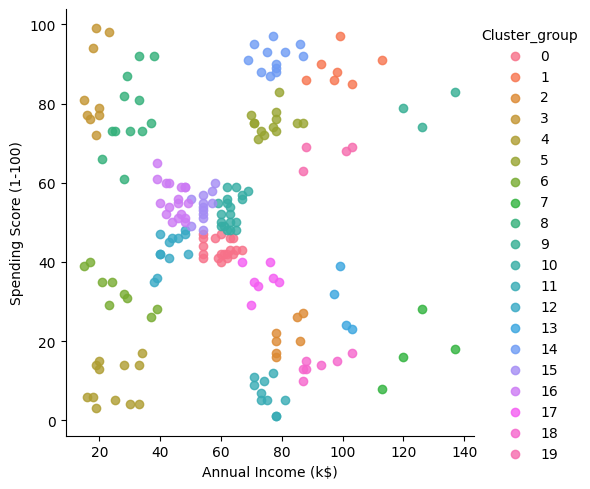

In [19]:
import seaborn as sns
facet = sns.lmplot(data = supervised, x = supervised.columns[3], y = supervised.columns[4], hue = supervised.columns[5], fit_reg = False, legend_out = True)